## Question 7.1:Linear algebra exercises
Given matrix $$A =\begin{bmatrix}
1 & 2 & 3\\
0 & -4 & 1\\
0 & 3 & -1
\end{bmatrix} 	
$$

1. What is the determinant of A?
2. What is the solution $ (x,y,z)$ of the following set of equations?
   $$ x+2y+3z=2$$
   $$-4y+z=2 $$
   $$3y-z=-1 $$

3. Is A orthogonal?
An Eigenvector is a vector whose direction remains unchanged when a linear transformation is applied to it. If A is a matrix and $\vec{v}$ an Eigenvector, then if $A\vec{v}=\lambda \vec{v}$ we call  an Eigenvalue. Eigenvectors and Eigenvalues have many important applications in computer vision and machine learning.

4. Give the Eigenvalues of A

In [1]:
import numpy as np
from numpy import linalg as la

# We want to suppress printing of small floating point values using scientific notation 
np.set_printoptions(suppress=True)

A = np.array([1, 2, 3,  0, -4, 1,  0, 3, -1]).reshape(3, 3)
print(f"Matrix A =\n{A}\n")

print(f"1. The determinant of A is det(A) = {la.det(A)}\n")

b = np.array([2, 2, -1])
Ainv = la.inv(A)
xyz = Ainv@b              # @ dot product

print(f"2. The solution: x, y, z = {xyz}\n")

print(f"Inverse:\n{Ainv}")

print(f"3. For A to be orthogonal, the A dot product with transpose of A = Identity matrix and the inverse of A = transpose of A\n")

print(f"A^T = I: \n{A@A.T}\n{A@A.T==np.identity(3)}\n")

print(f"A^-1=A^T: \n{Ainv}\n={A.T}\n{Ainv==A.T}")

print("A is not orthogonal")

# ----- Eigenvector

Lambda, v = la.eig(A)
print(f"\nEigenvalues of A are: {Lambda}")

Matrix A =
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]

1. The determinant of A is det(A) = 1.0

2. The solution: x, y, z = [10. -1. -2.]

Inverse:
[[ 1. 11. 14.]
 [-0. -1. -1.]
 [-0. -3. -4.]]
3. For A to be orthogonal, the A dot product with transpose of A = Identity matrix and the inverse of A = transpose of A

A^T = I: 
[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]
[[False False False]
 [False False False]
 [False False False]]

A^-1=A^T: 
[[ 1. 11. 14.]
 [-0. -1. -1.]
 [-0. -3. -4.]]
=[[ 1  0  0]
 [ 2 -4  3]
 [ 3  1 -1]]
[[ True False False]
 [False False False]
 [False False False]]
A is not orthogonal

Eigenvalues of A are: [ 1.         -4.79128785 -0.20871215]


## Question 7.3 : Applying a rotation matrix

1. Create the composed matrix E from equation (7.15). The result must be:
```

[[-0.06698874 -0.87275577 -0.48353891]
[ 0.49272847 -0.45034696  0.74458463]
[-0.86760081 -0.1883746   0.46019978]]

```
2. Prove that the composed matrix is indeed a rotation matrix.

3. Every rotation matrix must have one real Eigenvalue $\lambda = 1$ (i.e. for a vector aligned with a rotation axis). Prove that this also applies to E.

4. The galactic pole (i.e. the pole in the galactic sky system) is given in degrees in equatorial coordinates R.A. and Dec. by $$(\alpha = 192.25, \delta = 27.4)$$

   $$ \vec{r}=\begin{bmatrix}
x\\y\\z
\end{bmatrix}=\begin{bmatrix} \cos\delta\cos\alpha\\ \cos\delta\sin\alpha \\ \sin\delta \end{bmatrix} $$	

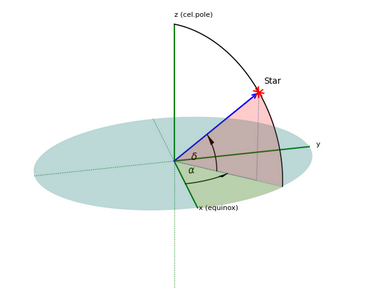

According to this formula, the angles $(\alpha, \delta)$ define a normalized vector (length 1) in the equatorial system equal to v = [-0.86760081, -0.1883746, 0.46019978]. Prove that v follows from equation (7.16) and that the norm of v is 1.0.

<mark>Prove that when you rotate this vector with rotation matrix E, the result is a vector v2 = [0,0,1] which has only a z component in the galactic system and therefore represents the galactic pole.</mark>


$$E = E_z(180-123)\cdot E_y(90-27.4)\cdot E_z(192.25)$$

$$E_z(\alpha)=\begin{bmatrix}\cos\alpha&-\sin\alpha&0\\-\sin\alpha &\cos\alpha& 0\\0&0&1\end{bmatrix}=180-123$$

In [2]:
from math import sin, cos
import numpy as np
from numpy import linalg as la
from numpy.linalg import norm

Alpha_deg = 180-123
Beta_deg = 90-27.4
Theta_deg = 192.25

Alpha = np.radians(Alpha_deg)
Beta = np.radians(Beta_deg)
Theta = np.radians(Theta_deg)

# 1st Rotation about z axis:
R_z1 = np.array([cos(Alpha), -sin(Alpha), 0,   sin(Alpha), cos(Alpha), 0,    0, 0, 1]).reshape(3,3)

# 2nd Rotation about y-axis:
R_y = np.array([cos(Beta), 0, sin(Beta),    0, 1, 0,   -sin(Beta), 0, cos(Beta)]).reshape(3,3)

# 3rd Rotation about z-axis again
R_z2 = np.array([cos(Theta), -sin(Theta), 0,   sin(Theta), cos(Theta), 0,    0, 0, 1]).reshape(3,3)

# Rotation Matrix E

E1 = R_z2@R_y@R_z1    # ORDER OF ROTATIONS IS IMPORTANT
E = R_z1 @R_y@R_z2   # THIS ONE IS CORRECT


print(f"E = \n{E}")

# 2. Prove it is a rotation matrix

print(f"\nFor it to be a rotation atrix, the determinant should equal 1 and the transpose is equal to the inverse matrix.\n")
print(f"det(E)={la.det(E)}\n")
print(f"{E.T}\n{la.inv(E)}\n")

# 3. Prove Eigenvalue = 1

Lambda, v = la.eig(E)

print(f"The Eigenvalues of E are: {Lambda}\n")

# 4. galactic pole transformation

alpha_gal = np.radians(192.25)    # galactic pole in equatorial coordinates
delta_gal =np.radians(27.4)

v = np.array([-0.86760081, -0.1883746, 0.46019978]).reshape(3, 1)

r = np.array([cos(delta_gal)*cos(alpha_gal), cos(delta_gal)*sin(alpha_gal), sin(delta_gal)]).reshape(3,1)

print(f"r vector when given the angles, gives: \n{r}\n")

# 5. Norm

print(f"Norm is : {norm(v)}\n")

# 6. Find v2 = (0,0,1)

print(E)
print(r)
v2 = E@r

print(v2)

E = 
[[-0.06698874  0.87275577  0.48353891]
 [-0.49272847 -0.45034696  0.74458463]
 [ 0.86760081 -0.1883746   0.46019978]]

For it to be a rotation atrix, the determinant should equal 1 and the transpose is equal to the inverse matrix.

det(E)=1.0

[[-0.06698874 -0.49272847  0.86760081]
 [ 0.87275577 -0.45034696 -0.1883746 ]
 [ 0.48353891  0.74458463  0.46019978]]
[[-0.06698874 -0.49272847  0.86760081]
 [ 0.87275577 -0.45034696 -0.1883746 ]
 [ 0.48353891  0.74458463  0.46019978]]

The Eigenvalues of E are: [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]

r vector when given the angles, gives: 
[[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]

Norm is : 0.9999999964749322

[[-0.06698874  0.87275577  0.48353891]
 [-0.49272847 -0.45034696  0.74458463]
 [ 0.86760081 -0.1883746   0.46019978]]
[[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]
[[ 0.11623897]
 [ 0.85498323]
 [-0.50546234]]


In [3]:
def x_rotation(a):
    return np.array([1, 0, 0,  0, cos(a), sin(a),  0, -sin(a), cos(a)]).reshape(3,3)

def y_rotation(a):
    return np.array([cos(a), 0, -sin(a),    0, 1, 0,   sin(a), 0, cos(a)]).reshape(3,3)

def z_rotation(d):
    return np.array([cos(d), sin(d), 0,   -sin(d), cos(d), 0,    0, 0, 1]).reshape(3,3)

R = x_rotation(alpha)@y_rotation(alpha)@z_rotation(delta)

NameError: name 'alpha' is not defined

## Question 7.5 : Interpolating polynomial

Given the set data points:
```
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
```

Use function numpy.linalg.solve() to find the coefficients of the interpolating polynomial that goes through all these data points.

Make a plot of both the data and interpolating polynomial.

Your implementation must also be able to deal with arbitrary length arrays x and y with different data than in the arrays above, so you have to use loops.

Show both code and plot. 

---
We have the set of points:

p1 = (2,   0.5)
p2 = (2.5, 0.4)
p3 = (4,   0.25)

$$f(x) = a_2x^2+a_1x+a_0$$ 
where $a_2$ = x value, $a_1 = \sqrt{\text{x value}}$, $a_0$ = usually 1

Or when we have multiple data points, the first row of the matrix is 
$$x_i^{(n-1)}, x_i^{(n-2)}, ..., x_i, 1$$

---

[  -0.00021712    0.01099256   -0.23905976    2.91867714  -21.93313594
  104.54407423 -313.63355567  565.81223696 -551.00314587  218.58233189]


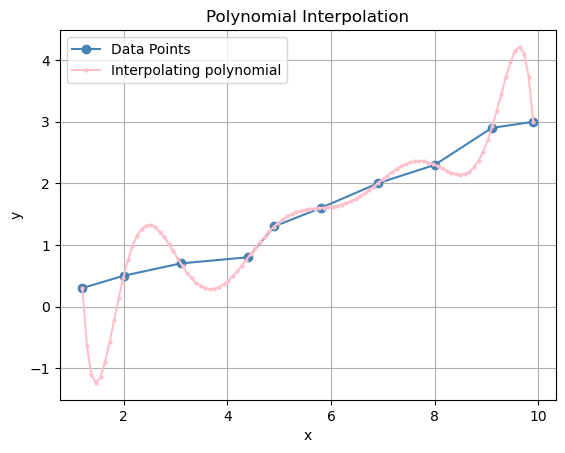

In [19]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

n = len(x)

# METHOD 1

# Create matrix with all zeroes first
A = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        A[i, j] = x[i]**(n-1-j)

coeff = np.linalg.solve(A, y)

print(coeff)

# --------- METHOD 2 -----------
A_2 = np.array([ [ x[i]**(n-1-j) for j in range(n) ] for i in range(n)])
# ------------------------------

# Plot of data points

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(x, y, color='steelblue', marker='o', label='Data Points')

# Plot of polynomial

x_poly = np.linspace(min(x), max(x), 100)

y_poly = []

for xi in x_poly:
    yi = 0
    for j in range(n):
        yi += coeff[j] * (xi**(n-1-j))
    y_poly.append(yi)

ax.plot(x_poly, y_poly, color='pink', marker='o', markersize=2, label='Interpolating polynomial')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Polynomial Interpolation')
ax.legend()
ax.grid()

plt.show()


## Question 7.6 : Cubic splines and OOP

Given the data points:
```
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
```
Use function interp1d() with argument kind='cubic' to find the cubic spline that goes through all these data points.

1. Make a plot of both the data and interpolating spline.

2. We mentioned that this is a superior choice than the polynomial interpolation. Compared to the plot you make in Question 7.5, share your thought.

3. Create a object oriented code called interpolation. With inputs x and y, this object can provide interpolation functions of (1) linear, (2) polynomial, and (3) spline interpolation.

4. In this object, create another function that allows user inputs any $\hat{X}$
 within the range of x, and one of the arguments for this function allow user to choose which interpolation functions to use for interpolation.

5. Use this function to calculate the corresponding $\hat{Y}$ using linear, polynomial, and spline interpolation.


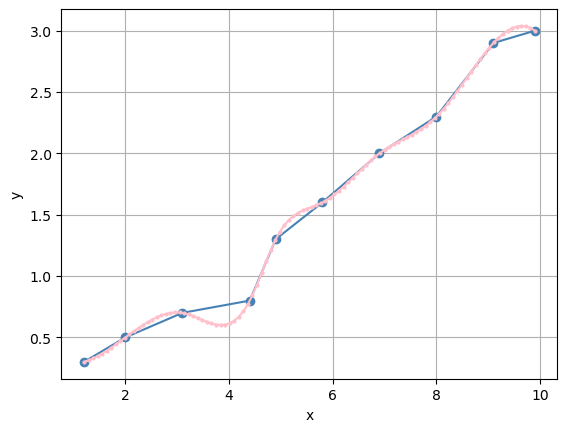

The polynomial interpolation is more 'free-form', while this interpolation method follows the data points more


In [14]:
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(min(x), max(x), 100)
newy = f(newx)

fig = figure()
ax = fig.add_subplot(1,1,1)

ax.plot(x, y, 'steelblue', marker='o', label='Data Points')
ax.plot(newx, newy, 'pink', marker='o', markersize=2, label='Interpolating spline')

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.grid()
64.13234247590542
show()

# ---------- 2 --------------

print("The polynomial interpolation is more 'free-form', while this interpolation method follows the data points more")
 

In [20]:
# --------- 3. --------------
from scipy import interpolate as ip
import numpy as np
from scipy import interpolate as ip

class interpolation:
    def __init__(self, x, y):
        self.x = np.array(x)
        self.y = np.array(y)
        self.n = len(x)

    def linear(self, newx):
        # find interval containing new x
        for i in range(self.n-1):
            if self.x[i] <= newx <= self.x[i+1]:
                x1, x2 = self.x[i], self.x[i+1]
                y1, y2 = self.y[i], self.y[i+1]
                return y1 + (y2-y1)*(newx - x1)/(x2-x1)

    def polynomial(self, newx):
        A = np.zeros((self.n, self.n))
        for i in range(self.n):
            for j in range(self.n):
                A[i, j] = self.x[i] **(self.n-1-j)

        coeff = np.linalg.solve(A, self.y)

        newy = 0

        for j in range(self.n):
            newy += coeff[j]*(newx**(self.n-1-j))

        return newy

    def spline(self, newx):
        f = ip.interp1d(self.x, self.y, kind='cubic')
        newy = f(newx)
        return newy

    def Method(self):

        newx = float(input("Enter value for x: "))
        method = input("Enter method (linear/polynomial/spline: ")

        linear_Y = self.linear(newx)
        polynomial_Y = self.polynomial(newx)
        spline_Y = self.spline(newx)

        if method == "linear":
            result = self.linear(newx)
            print(f"Linear interpolation at x = {newx}: {result:.5f}")
            print(f"Y = {linear_Y:.5f}")

        elif method == "polynomial":
            result = self.polynomial(newx)
            print(f"Polynomial interpolation at x = {newx}: {result:.5f}")
            print(f"Y = {polynomial_Y:.5f}")

        elif method == "spline":
            result = self.spline(newx)
            print(f"Spline interpolation at x = {newx}: {result:.5f}")
            print(f"Y = {spline_Y:.5f}")

        else:
            print("Method not recognised. Choose linear, polynomial or spline")
64.13234247590542

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])  

interp = interpolation(x, y)
interp.Method()

Enter value for x:  6
Enter method (linear/polynomial/spline:  linear


Linear interpolation at x = 6.0: 1.67273
Y = 1.67273


## Question 7.7 : Bilinear interpolation

In section 32.2 of this notebook you can find a formula that calculate the interpolated intensity in a rectangular grid of 4 pixel values.

Copy this formula and add it in your notebook.

Use the formula to find an interpolated intensity of I = np.array([[2.0,4.1], [2.5,3.8]]) at position x=0.2, y=0.7.

In [16]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at 
       which we want to interpolate. 'iF' must be bigger or equal to 0 and 
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]
    
    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:        
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]  
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])

row_y = 0.7
col_x = 0.2

Iintp = bilinearIP(I, col_x, row_y)

if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")

The interpolated intensity at i,j=0.7,0.2 => x, y=0.20.7 is 2.658000


## Question 7.10 : Fitting the Lemaitre-Hubble relation

Recall week 3, you have practiced to find the parameters of the Hubble law, which is a linear relationship. In this exercise, we will assume a linear relation: $y=a+bx$ for the Hubble's law again, and request you to use scipy.optimize.leastsq() and scipy.optimize.curve_fit() to find the best-fitted parameters for this linear relationship. 

The measured distances (Mpc) and velocities (km/s), including their uncertainties, from an observer, are listed below. 

```
d(Mpc)    v(km/s)    error in d    error in v
==============================================
18.49      2094.75    0.3           100
35.48      2320.87    2.2           120
........

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]
```
- Follow the instruction in the notebook and use scipy.optimize.leastsq() with the consideration of velocity uncertainties to find the most optimal parameters. 
- Look it up (online and notebook) to use scipy.optimize.curve_fit() with the consideration of velocity uncertainties to find the most optimal parameters.
- Create a plot with these data points as markers, choose a marker different from the default.

- Then, plot both relationships on the same plots and write the relationship in their labels. 

Intercept beta0=69.9377803016813, slope beta1=64.13234247590542
====== LEASTSQ RESULTS ==========
Params:                          [69.93805979 64.13233494]
Unscaled standard error(s):      [47.32288249  1.52711792]
Scaled standard error(s):        [348.23437453  11.23758582]
Degrees of freedom:              11
Chi^2 min:                       595.6533407328835
Reduced Chi squared:             54.15030370298941
Iterations:                      Not returned by leastsq()
Number of function evaluations:  7
[69.9377803016813, 64.13234247590542] [69.93805979 64.13233494]


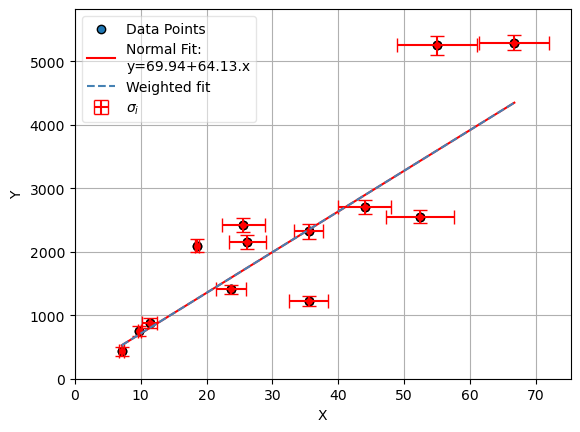

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

data = np.asarray(data)

x = data[0::4]   # distances
y = data[1::4]   # velocities
error_x = data[2::4]
error_y = data[3::4]

N = x.size

# Define Hubble law: y = a + b * x

def model(x, beta0, beta1):
    return beta0 + beta1 * x

# beta0 = a = 0, beta1 = b = 70

# Initial values
beta0 = 0
beta1 = 70

beta, pcov = curve_fit(model, x, y, sigma=error_y, absolute_sigma=True)  # Fitting
print(f"Intercept beta0={beta[0]}, slope beta1={beta[1]}")

# Absolute_sigma = True If we trust the errors in our observations as weights

# Errors
beta0, beta1 = beta
dbeta = np.sqrt(np.diag(pcov))   # standard errors

# Calculate end points for the best straight line
X = np.array([x.min(),x.max()])
Y = model(X, *beta)

fig = plt.figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, marker='o', ec='k', label="Data Points")
frame.errorbar(x, y, xerr=error_x, yerr=error_y, color='r', marker='', label=r"$\sigma_i$", ls='', capsize=5)
frame.set_xlabel('X')
frame.set_ylabel('Y')
label = f"Normal Fit:\ny={beta[0]:.2f}+{beta[1]:.2f}.x"
frame.plot(X, Y, label=label, color='red')

# --------------------------------------------

# Calculate reduced Chi squared

ri = (y - model(x, beta0, beta1))/error_y  # Weighted residuals
chi2 = (ri*ri).sum()

dof = len(x) - len(beta)  # Degrees of freedom

rchi2 = chi2/(N-dof)

# scipy.optimize.leastsq()

def model_leastsq(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x

def residuals(beta, x, y, error_y):
    return (y - model_leastsq(beta, x)) / error_y

beta_start = [0, 70.0]

data = (x, y, error_y)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1) 
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results 

# Convert unscaled standard errors to scaled standard errors 
if not pcov is None: 
    # Note that 'fvec' are residuals, not function 
    # values according to the documentation 
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()       
    perror = np.sqrt(pcov.diagonal())        # Trusted as the weights are realistic 
    dof = len(fvec) - len(beta)              # Number of degrees of freedom   
    # Uncertainties for unweighted data 
    sderr = perror * np.sqrt(chi2/dof) 

print( "====== LEASTSQ RESULTS =========="          )
print( "Params:                         ", beta     )
print( "Unscaled standard error(s):     ", perror   )
print( "Scaled standard error(s):       ", sderr    )
print( "Degrees of freedom:             ", dof      )
print( "Chi^2 min:                      ", chi2     )
print( "Reduced Chi squared:            ", chi2/dof )
print( "Iterations:                     ", "Not returned by leastsq()" )
print( "Number of function evaluations: ", infodict['nfev'] )

beta_lsqwei = beta

beta_lsq = [69.9377803016813, 64.13234247590542]

# plot of leastsq

frame.scatter(x, y, marker='o', ec='k', color='r')
xmin = x.min(); xmax = x.max()
ymin = model_leastsq(beta_lsq,xmin); ymax = model_leastsq(beta_lsq,xmax)

ymin = model_leastsq(beta_lsqwei,xmin); ymax = model_leastsq(beta_lsqwei,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Weighted fit", color='steelblue', ls="--")
print(beta_lsq, beta_lsqwei)
frame.set_xlabel('X')
frame.set_ylabel('Y')
frame.set_xlim(0, None)
frame.set_ylim(0, 1.1*y.max())
frame.legend(fancybox=True, framealpha=0.5)
frame.grid(True)

plt.show()


## Question 7.14 :

## $\textcolor{red}{\text{(Week 8 Session Quiz)}}$ Question 8.1: Create your astronomy game